ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

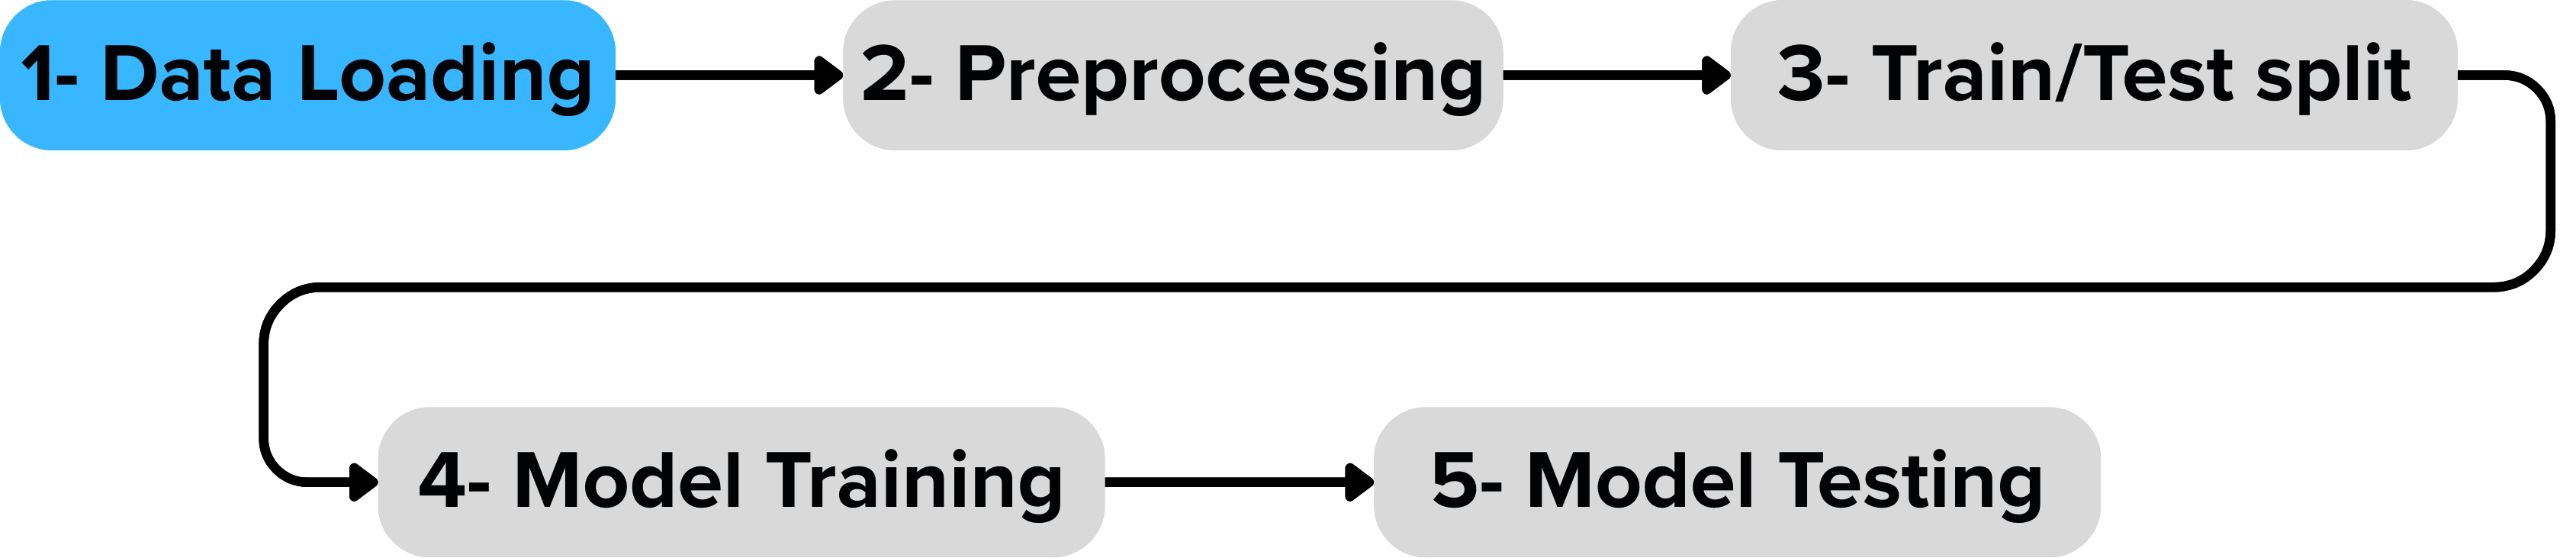

In [6]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [8]:
# Load Dataset
df = pd.read_csv("cleaned_makeup_reviews.csv")
df.head(-1)

/var/folders/2j/gvpfw7kn42j5gln81jlqvr6r0000gn/T/ipykernel_57528/708520188.py:2: DtypeWarning: Columns (15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cleaned_makeup_reviews.csv")


,unique_review_id,product_link_id,review_id,type,id,ugc_id,legacy_id,internal_review_id,headline,nickname,...,locale,location,bottom_line,product_page_id,upc,gtin,is_staff_reviewer,is_verified_buyer,is_verified_reviewer,helpful_score
0,1,8,521867580,image,521867563.0,NaN,NaN,-1,2C3 Fresco,Dinara,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
1,2,8,485614895,image,485614799.0,NaN,NaN,-1,Glowing Skin!,Stephie,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
2,3,8,485250956,image,485250927.0,NaN,NaN,-1,Love it,Cgbanks30,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
3,4,8,485086522,video,485086531.0,NaN,NaN,-1,Horrible allergic reaction,Genny,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
4,5,8,482905142,image,482905180.0,NaN,NaN,-1,Futurist Skin tint,Santro3822,...,NaN,NaN,NaN,NaN,NaN,NaN,f,f,f,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314023,314024,1153,454436842,pure_text,NaN,454436842.0,352166777.0,352166777,This is my second one !,Faith,...,en_US,Ocala fl,Yes,xlsImpprod12011207,8.008978e+11,8.008978e+11,f,t,t,1482
314024,314025,1135,525249842,pure_text,NaN,525249842.0,402675183.0,402675183,Messy,V,...,en_US,"Charleston, SC",NaN,pimprod2037010,1.976890e+11,1.976890e+11,f,f,f,1504
314025,314026,1135,524832825,pure_text,NaN,524832825.0,402423574.0,402423574,Horrible applicator,TjRivre,...,en_US,Little Rock,NaN,pimprod2037010,1.976890e+11,1.976890e+11,f,f,f,1138
314026,314027,1135,524524028,pure_text,NaN,524524028.0,402281837.0,402281837,Stays on and blends amazing!,Ahna,...,en_US,"Philadelphia,Pa",NaN,pimprod2037010,1.976890e+11,1.976890e+11,f,f,f,1566


### Check Missing Values

In [ ]:
# Check all values
print(df.isna().sum())

unique_review_id             0
product_link_id              0
review_id                    0
type                         0
id                       52180
ugc_id                  261849
legacy_id               261849
internal_review_id           0
headline                     0
nickname                  1299
created_date                 0
updated_date                 0
rating                       0
helpful_votes                0
not_helpful_votes            0
uri                      52180
comments                261865
locale                  261849
location                261859
bottom_line             290080
product_page_id         261849
upc                     278322
gtin                    276373
is_staff_reviewer            0
is_verified_buyer            0
is_verified_reviewer         0
helpful_score                0
dtype: int64


This shows number of missing values in each collumn, some columns have missing data but important columns like rating,helful votes ans not helful votes have no missing values

### Check duplicate rows

In [17]:
# checking duplicate rows
df.duplicated().sum()

np.int64(0)

there is no duplicated rows in the dataset

### No. of rows and columns

In [ ]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")
print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (314029, 27) 

number of rows:  314029
number of columns:  27


### Data type of columns

In [19]:
# viewing the data types of columns
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314029 entries, 0 to 314028
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   unique_review_id      314029 non-null  int64  
 1   product_link_id       314029 non-null  int64  
 2   review_id             314029 non-null  int64  
 3   type                  314029 non-null  object 
 4   id                    261849 non-null  float64
 5   ugc_id                52180 non-null   float64
 6   legacy_id             52180 non-null   float64
 7   internal_review_id    314029 non-null  int64  
 8   headline              314029 non-null  object 
 9   nickname              312730 non-null  object 
 10  created_date          314029 non-null  object 
 11  updated_date          314029 non-null  object 
 12  rating                314029 non-null  int64  
 13  helpful_votes         314029 non-null  int64  
 14  not_helpful_votes     314029 non-null  int64  
 15  

The data set contains various types of data such as numerical, categorical and text data.
The columns Rating and Helpful votes are numeric, they will be used for analysis

In [39]:
df['created_date']= pd.to_datetime(df['created_date'],errors='coerce')
df['rating']=pd.to_numeric(pd.to_numeric(df['rating'], errors='coerce'))
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype                    
---  ------                --------------  -----                    
 0   unique_review_id      0 non-null      int64                    
 1   product_link_id       0 non-null      int64                    
 2   review_id             0 non-null      int64                    
 3   type                  0 non-null      object                   
 4   id                    0 non-null      float64                  
 5   ugc_id                0 non-null      float64                  
 6   legacy_id             0 non-null      float64                  
 7   internal_review_id    0 non-null      int64                    
 8   headline              0 non-null      object                   
 9   nickname              0 non-null      object                   
 10  created_date          0 non-null      datetime64[ns, UTC-04:00]
 11  updated_da

The missing values were removed and data types were corrected to prepare the dataset for analysis.

In [22]:
# Statistical summary
df.describe(include='all')

,unique_review_id,product_link_id,review_id,type,id,ugc_id,legacy_id,internal_review_id,headline,nickname,...,locale,location,bottom_line,product_page_id,upc,gtin,is_staff_reviewer,is_verified_buyer,is_verified_reviewer,helpful_score
count,314029.000000,314029.000000,3.140290e+05,314029,2.618490e+05,5.218000e+04,5.218000e+04,3.140290e+05,314029,312730,...,52180,52170,23949,52180,3.570700e+04,3.765600e+04,314029,314029,314029,314029.000000
unique,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,38626,31412,...,1,6508,2,1292,NaN,NaN,1,2,2,NaN
top,NaN,NaN,NaN,image,NaN,NaN,NaN,NaN,Love it,anonymous,...,en_US,undisclosed,Yes,xlsImpprod15921204,NaN,NaN,f,f,f,NaN
freq,NaN,NaN,NaN,255902,NaN,NaN,NaN,NaN,2864,1723,...,52180,4218,18955,135,NaN,NaN,314029,303970,294973,NaN
mean,157015.000000,592.532050,4.277111e+08,NaN,4.145452e+08,4.937801e+08,3.801881e+08,6.317319e+07,NaN,NaN,...,NaN,NaN,NaN,NaN,1.288934e+12,1.411508e+12,NaN,NaN,NaN,249.403090
min,1.000000,1.000000,3.122572e+07,NaN,3.122578e+07,1.907670e+08,7.420851e+07,-1.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,8.100008e+09,8.100008e+09,NaN,NaN,NaN,-1.000000
25%,78508.000000,189.000000,3.812897e+08,NaN,3.395951e+08,4.801449e+08,3.709407e+08,-1.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,1.953543e+11,3.029939e+11,NaN,NaN,NaN,-1.000000
50%,157015.000000,464.000000,4.685630e+08,NaN,4.580327e+08,5.109026e+08,3.918810e+08,-1.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,7.736020e+11,7.736027e+11,NaN,NaN,NaN,-1.000000
75%,235522.000000,1073.000000,5.096160e+08,NaN,5.073037e+08,5.223256e+08,4.009828e+08,-1.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,8.471370e+11,8.579000e+11,NaN,NaN,NaN,-1.000000
max,314029.000000,1460.000000,5.257408e+08,NaN,5.256673e+08,5.257408e+08,5.255636e+08,5.255636e+08,NaN,NaN,...,NaN,NaN,NaN,NaN,9.351748e+12,9.351748e+12,NaN,NaN,NaN,3908.000000


### Descriptive summary Statistics

### Univariate Analysis

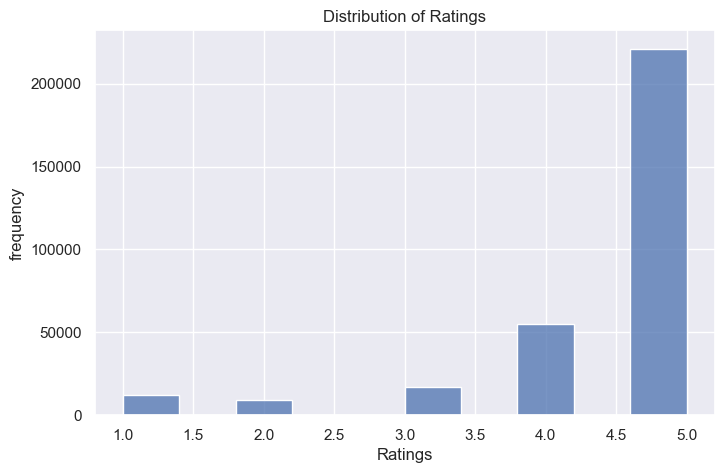

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Ratings")
plt.ylabel('frequency')
plt.show()

This histogram shows the distribution of product ratings
Most reviews are focused at higher ratings ( aroun 4 and 5 ) which is indicates that there is positive customer feedback, lower ratings shows less frequently

### Distribution of Helpful Votes

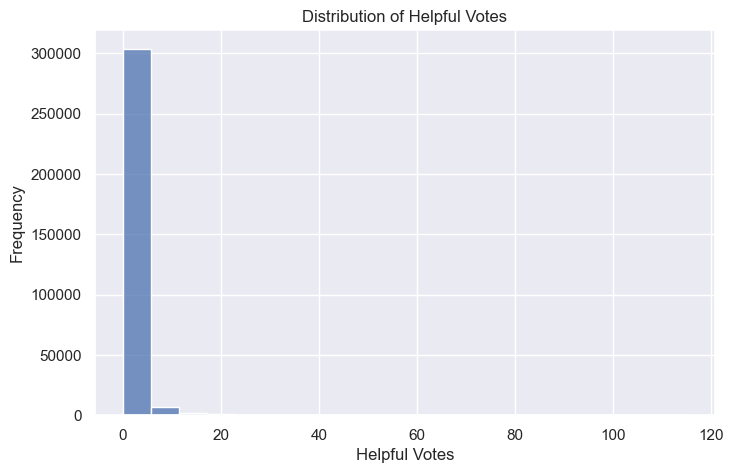

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['helpful_votes'], bins=20)
plt.title("Distribution of Helpful Votes")
plt.xlabel("Helpful Votes")
plt.ylabel("Frequency")
plt.show()

## Bivariate Analysis

### Rating vs Helpful Votes

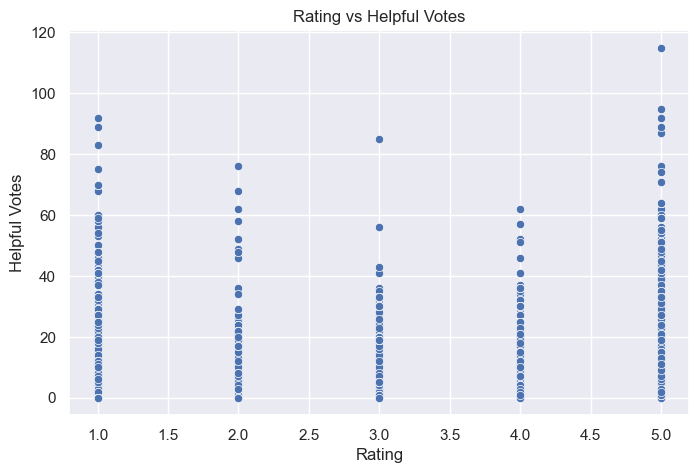

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['rating'], y=df['helpful_votes'])
plt.title("Rating vs Helpful Votes")
plt.xlabel("Rating")
plt.ylabel("Helpful Votes")
plt.show()

This plot shows the relationship between ratings and helpful votes. There is no clear strong pattern, but higher ratings tend to receive slightly more helpful votes.

### Average Rating by Product

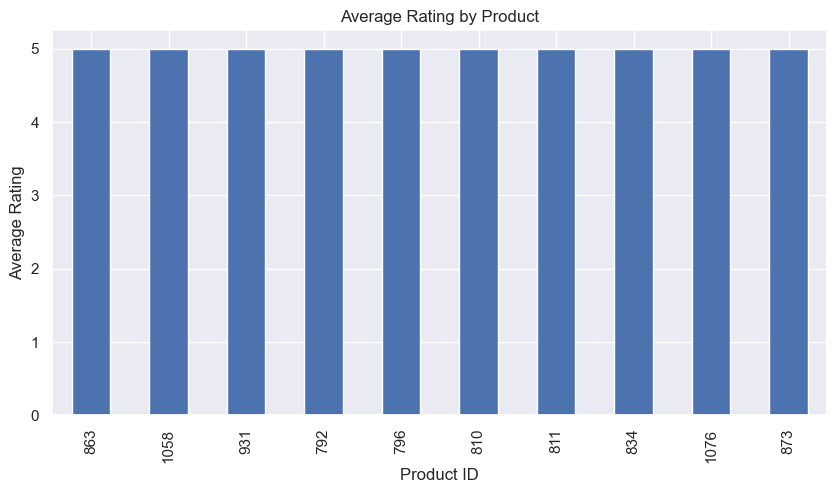

product_link_id
863     5.0
1058    5.0
931     5.0
792     5.0
796     5.0
810     5.0
811     5.0
834     5.0
1076    5.0
873     5.0
Name: rating, dtype: float64

In [32]:
product_rating = df.groupby('product_link_id')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_rating.head(10).plot(kind='bar')
plt.title("Average Rating by Product")
plt.ylabel("Average Rating")
plt.xlabel("Product ID")
plt.show()

product_rating.head(10)

This chart shows the average rating for different products. Most products have high average ratings, indicating overall customer satisfaction.

### Rating vs Helpful Votes

In [33]:
votes_by_rating = df.groupby('rating')['helpful_votes'].mean().sort_values(ascending=False)
votes_by_rating.head(10)

rating
1    2.166279
2    1.539462
3    0.863789
5    0.569495
4    0.413094
Name: helpful_votes, dtype: float64

This table shows the average number of helpful votes for each rating level. Lower ratings tend to receive slightly more helpful votes, possibly because detailed negative reviews attract attention.

### Review Length vs Helpful Votes

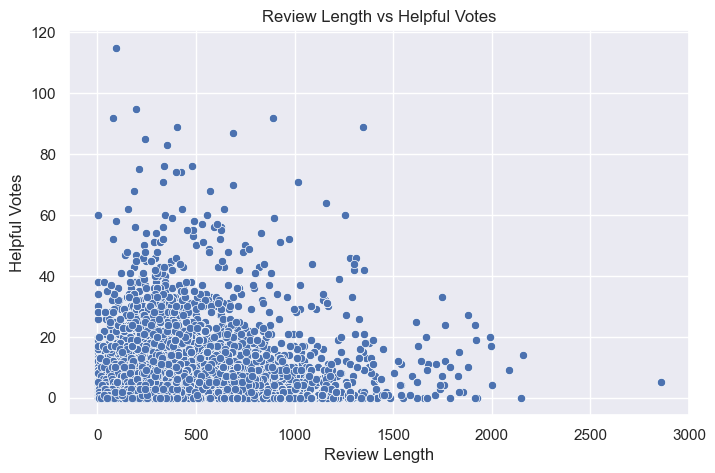

In [34]:

df['review_length'] = df['comments'].astype(str).apply(len)
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['review_length'], y=df['helpful_votes'])
plt.title("Review Length vs Helpful Votes")
plt.xlabel("Review Length")
plt.ylabel("Helpful Votes")
plt.show()

This plot shows the relationship between review length and helpful votes. Longer reviews tend to receive more helpful votes, suggesting that detailed reviews are more useful to users.

### Correlation Matrix

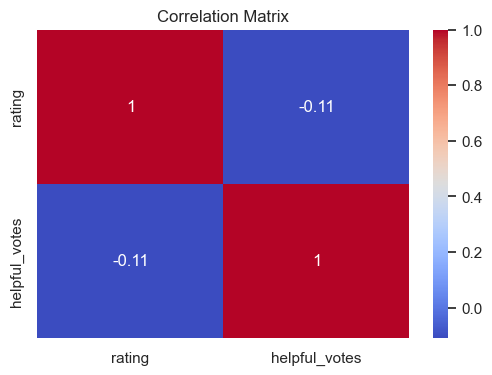

In [ ]:
plt.figure(figsize=(6,4))

numeric_cols = ['rating', 'helpful_votes']

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

The correlation between rating and helpful votes is weak (-0.11), indicating there is no strong relationship between them.

## Time-Based Analysis
### Reviews over Time

/var/folders/2j/gvpfw7kn42j5gln81jlqvr6r0000gn/T/ipykernel_57528/4279709441.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['created_date'].dt.to_period('M')


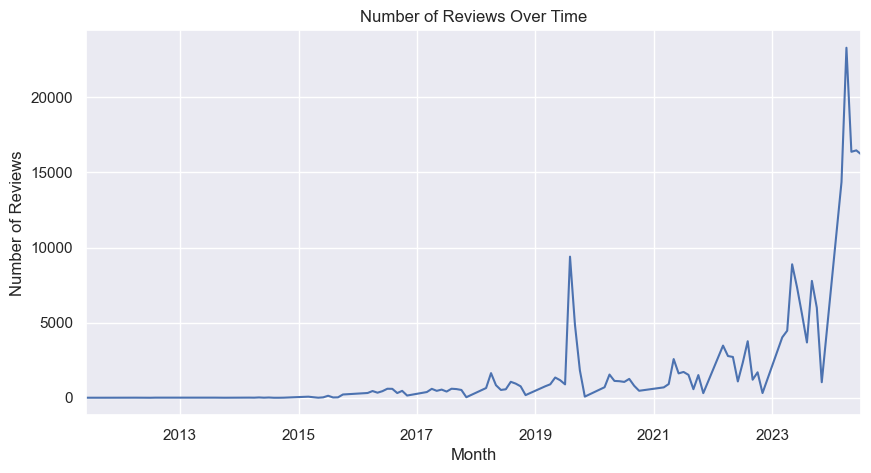

In [38]:

df['created_date'] = pd.to_datetime(df['created_date'])
df['month'] = df['created_date'].dt.to_period('M')
monthly_reviews = df.groupby('month').size()
plt.figure(figsize=(10,5))
monthly_reviews.plot()
plt.title("Number of Reviews Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

This plot shows the number of reviews over time. There is a noticeable increase in recent years, indicating growing user engagement.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file 
2. Dataset Description readme file
2. Jupyter Notebook
